In [ ]:
%pip install ibm-watsonx-ai

In [ ]:
from ibm_watsonx_ai import Credentials
from ibm_watsonx_ai.foundation_models import ModelInference
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames

credentials = Credentials(
                   url = "https://us-south.ml.cloud.ibm.com",
                   # api_key = "<YOUR_API_KEY>" # Normally you'd put an API key here, but we've got you covered here
                  )

params = {
    GenTextParamsMetaNames.DECODING_METHOD: "greedy",
	GenTextParamsMetaNames.MAX_NEW_TOKENS: 100
}

model = ModelInference(
    model_id='ibm/granite-3-3-8b-instruct',
    params=params,
    credentials=credentials,
    project_id="skills-network"
)

text = """
Only reply with the answer. What is the capital of Canada?
"""

print(model.generate(text)['results'][0]['generated_text'])



to execute the capital.py in the ide.. first click python button beside the code snippet .. which open the code  in the IDE.. which opens capital.py in cloud IDE (which seems almost vs code in cloud). Then copy the code into capital.py. from all the snippets 
open a terminal. 
run command

 python3.11 -m venv venv

 source venv/bin/activate

 pip install ibm-watsonx-ai==1.3.39

  python3.11 /home/project/genai_flask_app/capital.py

  [[ above command did not work.. had to change the model to ibm/granite-8b-code-instruct and then it got working
  ]]


output - 

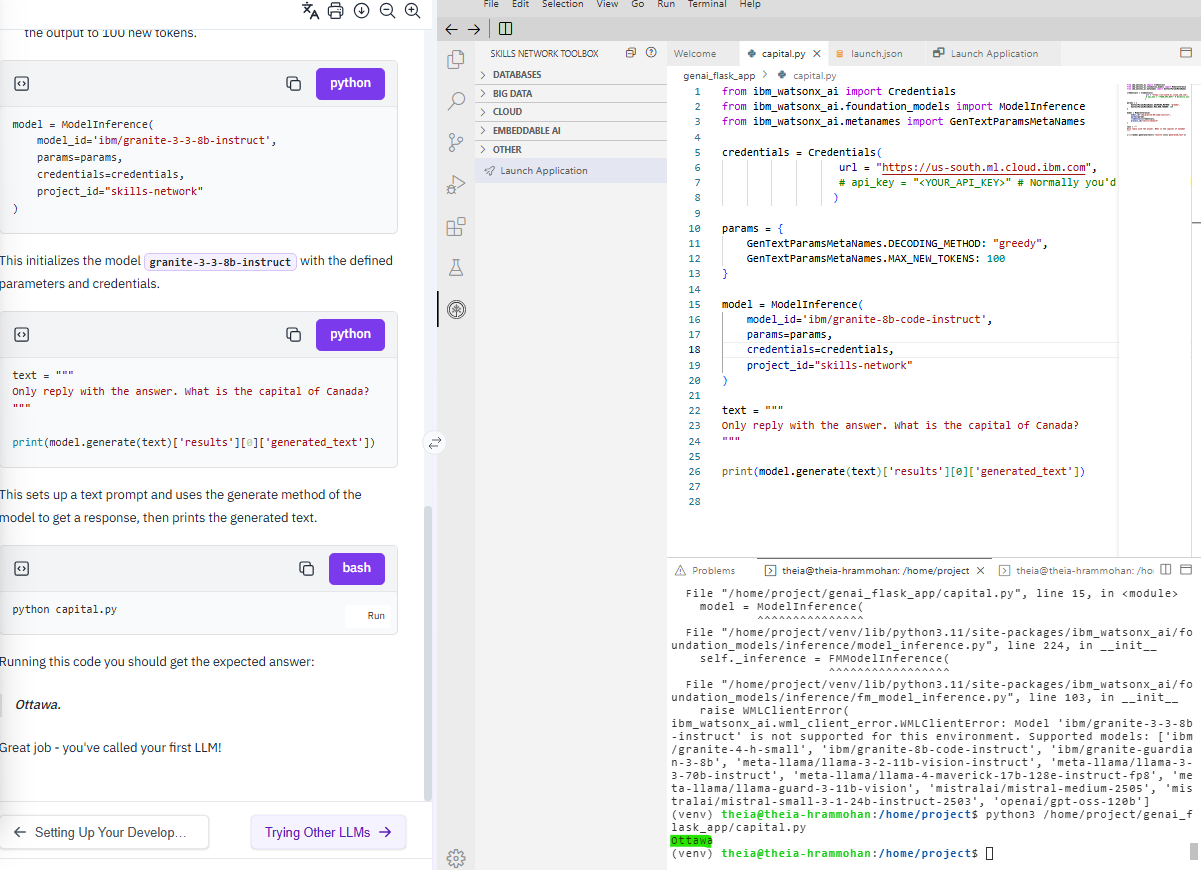

first LLM has been created  !!


Trying Other LLMs
There are numerous LLMs available from IBM and other providers, each with its own strengths and use cases. New models are constantly emerging, so it’s important to stay informed about the latest advancements in the field.

How to Choose the Right LLM
First of all, choosing an LLM model is deceptively complicated (it’s a whole topic in itself). While it’s tempting to focus on the specs alone—like token limits, training data, or number of parameters—these details will only take you so far. The real test comes when you evaluate how a model performs for your specific use cases.

Here are some important factors to consider when selecting a model:

Capabilities: Does the model meet your needs? For example, some models are multimodal, meaning they can handle images and text, while others are limited to text-only tasks.
Cost: How much does it cost to use the model, including both input and output tokens? Balancing cost with performance is key to ensuring long-term value.
Speed: How quickly does the model generate responses? In some use cases, speed is just as important as accuracy, especially in real-time applications.
Quality: How accurate and relevant are the model’s outputs for your tasks? You’ll need to run tests to evaluate if the responses meet your quality standards.
Other Considerations: Think about any specific vendors you may need to work with, licensing restrictions, or integrations with your existing systems.
Ultimately, you’ll want to experiment and run real-world tests to find the right fit for your needs. Specs can guide you, but hands-on testing against your own usecases is the only way to truly know if a model works for your unique scenarios.

Now let's try and update our code using a different LLM model, llama-4-maverick-17b-128e-instruct-fp8.

Make sure you still have capital.py open:

Now simply update the model from ibm/granite-3-3-8b-instruct to meta-llama/llama-4-maverick-17b-128e-instruct-fp8. 

Running the code, we get (Note: You will probably get a slightly different output)


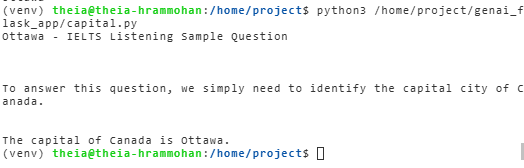

Hmm... not quite the answer we were expecting. Why is that? Don't worry, we'll explain in the next section!

Try using different models and see what you come up with!

Here's a list of some of the latest models available in WatsonX (as of September 15, 2025). Just replace the model_id in the code with one of the ones below and run the program again!

Here's a list of some of the latest models available in WatsonX (as of September 15, 2025). Just replace the model_id in the code with one of the ones below and run the program again!

Provider	model ID	Use Cases	Context Length	Price USD per million tokens
IBM	ibm/granite-3-8b-instruct	Supports questions and answers (Q&A), summarization, classification, generation, extraction, RAG, and coding tasks.	4096	0.2
IBM	ibm/granite-3-2b-instruct	Supports questions and answers (Q&A), summarization, classification, generation, extraction, RAG, and coding tasks.	4096	0.1
IBM	ibm/granite-13b-instruct-v2	Supports Q&A, summarization, classification, generation, extraction and RAG tasks.	8192	0.6
Meta	meta-llama/llama-4-maverick-17b-128e-instruct-fp8	Multimodal reasoning, long-context processing (10M tokens), code generation and analysis, multilingual operations (200 languages supported), STEM and logical reasoning.	128k	Input: 0.35 / Output: 1.40
Meta	meta-llama/llama-3-2-90b-vision-instruct	Supports Q&A, summarization, classification, generation, extraction, translation and RAG tasks in French, German, Portuguese, Spanish and English.	128k	2.00
Meta	meta-llama/llama-3-2-11b-vision-instruct	Supports image captioning, image-to-text transcription (OCR) including handwriting, data extraction and processing, context Q&A, object identification	128k	0.35
Mistral	mistralai/mistral-small-3-1-24b-instruct-2503	Supports Q&A, summarization, generation, coding, classification, extraction, translation and RAG tasks in French, German, Italian, Spanish and English.	128k	10.00
Google	google/flan-t5-xl	Supports Q&A, summarization, classification, generation, extraction and RAG tasks. Available for prompt-tuning	4096	0.6




Special Tokens & Prompt Formatting
We missed a very important step. Llama uses special tokens to improve its functionality, control, and adaptability across diverse tasks. Without special tokens, Llama’s responses can be unpredictable because it lacks the necessary cues to interpret the structure, context, or intent of the input. These tokens act as guides that tell the model how to respond.
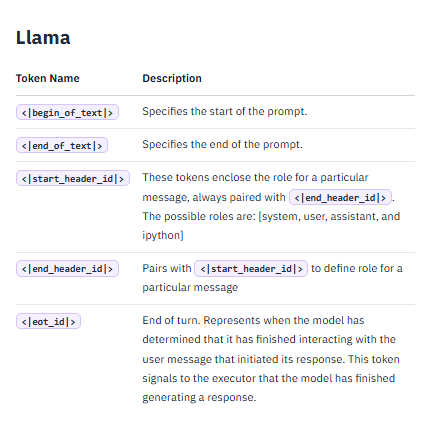

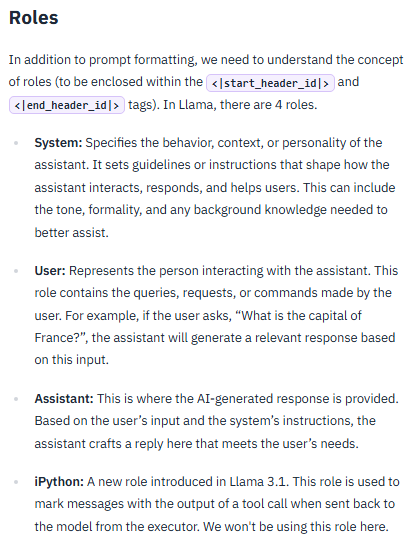

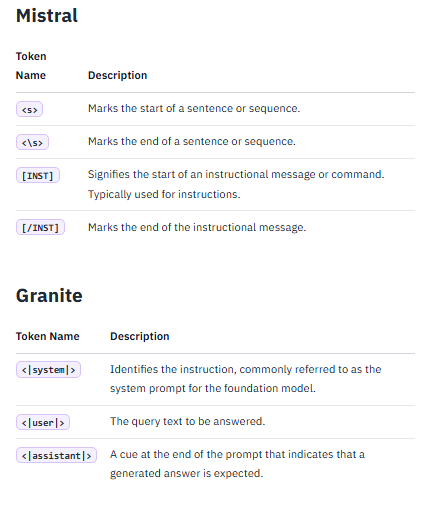


Prompting with Special Tokens
So let's update our code to use the aforementioned special tokens.


text = """
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert assistant who provides concise and accurate answers.<|eot_id|>

<|start_header_id|>user<|end_header_id|>
What is the capital of Canada?<|eot_id|>

<|start_header_id|>assistant<|end_header_id|>
"""


with this code when capital.py is execute we see correct answer even by illama

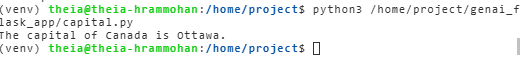



So Why Did That Happen?
Remember, while LLM's are impressively versatile, they aren't yet fully equipped for true logical reasoning, yet. They transform content into tokens and then predict the next token. This means that when asked, ‘Why did the chicken cross the road?’ an LLM might respond with ‘Is a common riddle joke’ just as likely as with ‘To get to the other side,’ as it’s selecting responses based on probability rather than understanding. By using special tokens to better define the role of the LLM, we gain tighter control over its responses, aligning outputs more closely with our intended outcomes.

Now try doing it with other models

<|system|> You are an expert assistant who provides concise and accurate answers. <|user|> What is the capital of France? <|assistant|> Mistral:

From Prompts to Structured Outputs
Special tokens give us better control over how a model responds, but we’re still dealing with raw text. In many real-world applications, we don’t just want plain sentences — we want structured data that can be parsed, stored, and acted on by our code.

For example, instead of getting:

The capital of Canada is Ottawa.


we might want:

{ "country": "Canada", "capital": "Ottawa" }


This kind of structure makes it much easier to integrate AI into applications — whether that’s filling a database, driving an API, or connecting to another service.

Managing prompts, roles, and output formatting manually can get messy fast. That’s where LangChain comes in.

What is LangChain?
LangChain provides an abstraction layer over multiple language models, allowing developers to use a consistent API and set of tools to switch between or combine different models, depending on their needs. It includes built-in utilities for managing prompts, chaining responses, parsing outputs, and structuring conversations, making it a powerful toolkit for building sophisticated AI applications.

Why Use LangChain?
Consistent and Modular Integration modular and reusable components simplify the integration of AI models into your application such as the ability to switch out models without major code changes.
Structured Outputs with JSON Parsers help ensure that responses from the language model are consistent and easily parsed
Support for Multi-Step Workflows allows you to create complex, multi-step workflows that involve multiple prompts communicating with multiple different models
Using LangChain in a GenAI application enables developers to build robust, efficient, and maintainable AI solutions by simplifying the management of model interactions and ensuring that outputs are structured and reliable. As a result, LangChain empowers developers to focus on higher-level functionality, enhancing the overall performance and usability of AI-driven applications.

Creating Your Flask Application
Now that we understand our AI models, let's start by creating the backbone of your Flask application. We'll set up a basic structure that we'll enhance with AI capabilities in the following steps.

Before we start coding, let's install the Flask and LangChain libraries:


pip install Flask langchain-ibm langchain

This command installs:

Flask for web development
LangChain libraries for advanced AI capabilities
Step 1: Create Your Main Application File
Create a new file named app.py:


Add the following code to set up a basic Flask app:


from flask import Flask, request, jsonify

app = Flask(__name__)

@app.route('/generate', methods=['POST'])
def generate():
    # This is where we'll add our AI logic later
    return jsonify({"message": "AI response will be generated here"})

if __name__ == '__main__':
    app.run(debug=True)



Let's break down this code:

We import necessary modules from Flask.
We create a Flask application instance.
We define a route /generate that will handle POST requests. This is where our AI logic will go.
For now, it returns a simple JSON response.
The if __name__ == '__main__': block ensures the Flask development server runs when we execute this file directly.
You've set up the foundation of your GenAI application. In the next sections, we'll integrate AI capabilities and enhance its functionality.



Integrating AI Models with LangChain
Now, let's integrate AI capabilities into your Flask application using the langchain library and various language models. We'll focus on creating a modular structure for easy maintenance and expansion.

Step 1: Create a Model Configuration File
First, let's create a configuration file to store our model parameters and credentials. Create a new file named config.py:
Add the following code:




from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams

# Model parameters
PARAMETERS = {
    GenParams.DECODING_METHOD: "greedy",
    GenParams.MAX_NEW_TOKENS: 256,
}

watsonx credentials
Note: Normally we'd need an API key, but in Skill's Network Cloud IDE will automatically handle that for you.
CREDENTIALS = {
    "url": "https://us-south.ml.cloud.ibm.com",
    "project_id": "skills-network"
}

# Model IDs
LLAMA_MODEL_ID = "meta-llama/llama-3-2-11b-vision-instruct"
GRANITE_MODEL_ID = "ibm/granite-3-3-8b-instruct"
MISTRAL_MODEL_ID = "mistralai/mistral-small-3-1-24b-instruct-2503"

This configuration file centralizes our model settings, making it easier to manage and update them.


Step 2: Create a Model Integration File
Now, let's create a file to handle our AI model integration. Create a new file named model.py:

from langchain_ibm import ChatWatsonx
from langchain.prompts import PromptTemplate
from config import PARAMETERS, LLAMA_MODEL_ID, GRANITE_MODEL_ID, MISTRAL_MODEL_ID


Let's break down the imports

ChatWatsonx will be our interface to interact with IBM Watsonx AI models.
PromptTemplate allows us to create dynamic prompts with placeholders for AI input.
PARAMETERS, LLAMA_MODEL_ID, etc. are the configuration values we defined earlier to set up our different AI models.

add this code - 

# Function to initialize a model
def initialize_model(model_id):
    return ChatWatsonx(
        model_id=model_id,
        url="https://us-south.ml.cloud.ibm.com",
        project_id="skills-network",
        params=PARAMETERS
    )

# Initialize models
llama_llm = initialize_model(LLAMA_MODEL_ID)
granite_llm = initialize_model(GRANITE_MODEL_ID)
mistral_llm = initialize_model(MISTRAL_MODEL_ID)

We will once again initialize our models, this time we're going to take advantage of LangChain's ChatWatsonx, a wrapper for WatsonX API client.

and then this code

# Prompt template
llama_template = PromptTemplate(
    template='''<|begin_of_text|><|start_header_id|>system<|end_header_id|>
{system_prompt}<|eot_id|><|start_header_id|>user<|end_header_id|>
{user_prompt}<|eot_id|><|start_header_id|>assistant<|end_header_id|>
''',
    input_variables=["system_prompt", "user_prompt"]
)

granite_template = PromptTemplate(
    template="<|system|>{system_prompt}\n\<|user|>{user_prompt}\n<|assistant|>",
    input_variables=["system_prompt", "user_prompt"]
)

mistral_template = PromptTemplate(
    template="<s>[INST]{system_prompt}\n{user_prompt}[/INST]",
    input_variables=["system_prompt", "user_prompt"]
)

To make our prompts more reusable and adaptable across our chats, we can use the PromptTemplate class. This allows us to define templates with placeholders that can be filled dynamically at runtime with specific inputs.

By defining placeholders like system_prompt, and user_prompt, these templates can be reused with different content, making them flexible for various interactions with AI models.

and then this code -
def get_ai_response(model, template, system_prompt, user_prompt):
    chain = template | model
    return chain.invoke({'system_prompt':system_prompt, 'user_prompt':user_prompt})

The functionget_ai_responseallows us to chain a prompt template and an AI model together. We can using the pipe operator|to directly take the output of the template and use that as the input of the model.

and then this code -

# Model-specific response functions
def llama_response(system_prompt, user_prompt):
    return get_ai_response(llama_llm, llama_template, system_prompt, user_prompt)

def granite_response(system_prompt, user_prompt):
    return get_ai_response(granite_llm, granite_template, system_prompt, user_prompt)

def mistral_response(system_prompt, user_prompt):
    return get_ai_response(mistral_llm, mistral_template, system_prompt, user_prompt)


The model-specific functions each call this generic function with the respective models and templates, ensuring that the appropriate format is used for each AI model when generating responses.

Let's break down this code:

We import necessary modules and our configuration.
We define a function initialize_model to create model instances, promoting code reuse.
We initialize our models using this function.
We create prompt templates for each model, as they may have different preferred formats.
The get_ai_response function handles the process of formatting prompts, getting responses
We define model-specific response functions that use the general get_ai_response function.
This modular approach allows for easy addition of new models or modification of existing ones.

now the full code of model.py is - 








In [ ]:
from langchain_ibm import ChatWatsonx
from langchain.prompts import PromptTemplate
from config import PARAMETERS, LLAMA_MODEL_ID, GRANITE_MODEL_ID, MISTRAL_MODEL_ID



# Function to initialize a model
def initialize_model(model_id):
    return ChatWatsonx(
        model_id=model_id,
        url="https://us-south.ml.cloud.ibm.com",
        project_id="skills-network",
        params=PARAMETERS
    )

# Initialize models
llama_llm = initialize_model(LLAMA_MODEL_ID)
granite_llm = initialize_model(GRANITE_MODEL_ID)
mistral_llm = initialize_model(MISTRAL_MODEL_ID)

# Prompt template
llama_template = PromptTemplate(
    template='''<|begin_of_text|><|start_header_id|>system<|end_header_id|>
{system_prompt}<|eot_id|><|start_header_id|>user<|end_header_id|>
{user_prompt}<|eot_id|><|start_header_id|>assistant<|end_header_id|>
''',
    input_variables=["system_prompt", "user_prompt"]
)

granite_template = PromptTemplate(
    template="<|system|>{system_prompt}\n\<|user|>{user_prompt}\n<|assistant|>",
    input_variables=["system_prompt", "user_prompt"]
)

mistral_template = PromptTemplate(
    template="<s>[INST]{system_prompt}\n{user_prompt}[/INST]",
    input_variables=["system_prompt", "user_prompt"]
)

def get_ai_response(model, template, system_prompt, user_prompt):
    chain = template | model
    return chain.invoke({'system_prompt':system_prompt, 'user_prompt':user_prompt})

# Model-specific response functions
def llama_response(system_prompt, user_prompt):
    return get_ai_response(llama_llm, llama_template, system_prompt, user_prompt)

def granite_response(system_prompt, user_prompt):
    return get_ai_response(granite_llm, granite_template, system_prompt, user_prompt)

def mistral_response(system_prompt, user_prompt):
    return get_ai_response(mistral_llm, mistral_template, system_prompt, user_prompt)



Sanity Check -

That was a lot of code, before we move on, let's try running the code and see what we have. Let's give all our models a test run by calling them all together as a function.

Create the file llm_test.py:

add following code

In [ ]:
from model import llama_response, granite_response, mistral_response

def call_all_models(system_prompt, user_prompt):
    llama_result = llama_response(system_prompt, user_prompt)
    granite_result = granite_response(system_prompt, user_prompt)
    mistral_result = mistral_response(system_prompt, user_prompt)

    print("Llama Response:\n", llama_result.content)
    print("\nGranite Response:\n", granite_result.content)
    print("\nMistral Response:\n", mistral_result.content)

# Example call to test all models
call_all_models("You are a helpful assistant who provides concise and accurate answers", "What is the capital of Canada? Tell me a cool fact about it as well")


And run the following:

python3.11 /home/project/genai_flask_app/llm_test.py

If everything went well, you should get an output similar to the following:

"" Llama Response: The capital of Canada is Ottawa. A cool fact about Ottawa is that it's home to the Rideau Canal, a UNESCO World Heritage Site and the oldest continuously operated canal in North America. During the winter months, the canal freezes over and becomes the world's largest naturally frozen ice skating rink, stretching 7.8 kilometers (4.8 miles) through the heart of the city. Granite Response: The capital of Canada is Ottawa. It's located on the south bank of the Ottawa River and is known for its historic architecture, museums, and vibrant cultural scene. A cool fact about Ottawa is that it's home to the world's largest indoor ice-skating rink, the Rideau Canal Skateway, which is also a UNESCO World Heritage Site. Mistral Response: The capital of Canada is Ottawa. A cool fact about Ottawa is that it is one of the coldest capitals in the world. During winter, temperatures can drop as low as -40°C (-40°F), making it a popular destination for winter sports and activities like ice skating on the Rideau Canal, which becomes the world's largest naturally frozen ice skating rink. ""


had to change the following to get the test working -

from langchain_core.prompts import PromptTemplate
in model.py

and file config.py

change GRANITE_MODEL_ID = "ibm/granite-3-3-8b-instruct" to 

GRANITE_MODEL_ID = "ibm/granite-8b-code-instruct

After these changes running the llm_test.py file prints the output - 

Llama Response:
 The capital of Canada is Ottawa. 

A cool fact: Ottawa is home to the Rideau Canal, a UNESCO World Heritage Site and the oldest continuously operated canal in North America. It's also the only canal in the world that is still used for both transportation and recreation, with over 1 million people skating on it during the winter months.

Granite Response:
 The capital of Canada is Ottawa. A fun fact about Ottawa is that it was founded by the government of Canada on September 5, 1858, at the same time as the United States. Only four months later, on September 9, 1861, the first US president, George Washington, arrived in Ottawa, making it the first official presidential landing in North America.

Mistral Response:
 The capital of Canada is **Ottawa**.

Cool fact: Ottawa is known as the world's most educated city, with over 50% of its residents having a bachelor's degree or higher.


Setting up JSON outputs
There's an important step we need to address: making sure the AI’s output follows a well-defined format. This is essential for taking the output and seamlessly integrating it into other systems, like a website.

We can use Pydantic to define a clear schema for the AI’s response, ensuring consistent structure and validation. This enforces the correct format, making data integration smoother and more reliable.



In [ ]:
from pydantic import BaseModel, Field
from langchain_core.output_parsers import JsonOutputParser


We'll use BaseModel and Field to define our JSON output structure. To make our lives a bit easier, we will also useJsonOutputParserto automatically parse and validate the AI’s output into the structured format we’ve defined.

In [ ]:
# Define JSON output structure
class AIResponse(BaseModel):
    summary: str = Field(description="Summary of the user's message")
    sentiment: int = Field(description="Sentiment score from 0 (negative) to 100 (positive)")
    response: str = Field(description="Suggested response to the user")


To seamlessly integrate this structure into our code, we use the JsonOutputParser. This parser ensures that the output returned by the AI is automatically validated and parsed into theAIResponseformat.

In [ ]:
# JSON output parser
json_parser = JsonOutputParser(pydantic_object=AIResponse)


Here, we define the expected output using the AIResponse Pydantic model, specifying fields like summary, sentiment, action, and response. The JsonOutputParser will ensure that the AI output conforms to this structure, providing well-formatted, validated data for further use in our application.

In [ ]:
def get_ai_response(model, template, system_prompt, user_prompt):
    chain = template | model | json_parser
    return chain.invoke({'system_prompt':system_prompt, 'user_prompt':user_prompt, 'format_prompt':json_parser.get_format_instructions()})


You can see that we add the json_parser to our chain and call json_parser.get_format_instructions() which will ultimately update our prompt with instructions to respond in well-structured JSON as defined by the AIResponse class.

Putting it all Together
So let's add this to the chain! To do this we need to addAIResponseandjson_parserto the top ofmodel.pyas well as adding adding another link to our chain object within get_ai_response. Your code should look like this:

In [ ]:
# model.Pretty

from langchain_ibm import WatsonxLLM
from langchain_ibm import ChatWatsonx
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field
from config import PARAMETERS, CREDENTIALS, LLAMA_MODEL_ID, GRANITE_MODEL_ID, MISTRAL_MODEL_ID

# Define JSON output structure
class AIResponse(BaseModel):
    summary: str = Field(description="Summary of the user's message")
    sentiment: int = Field(description="Sentiment score from 0 (negative) to 100 (positive)")
    response: str = Field(description="Suggested response to the user")

# JSON output parser
json_parser = JsonOutputParser(pydantic_object=AIResponse)

# Function to initialize a model
def initialize_model(model_id):
    return ChatWatsonx(
        model_id=model_id,
        url="https://us-south.ml.cloud.ibm.com",
        project_id="skills-network",
        params=PARAMETERS
    )

# Initialize models
llama_llm = initialize_model(LLAMA_MODEL_ID)
granite_llm = initialize_model(GRANITE_MODEL_ID)
mistral_llm = initialize_model(MISTRAL_MODEL_ID)

# Prompt templates
llama_template = PromptTemplate(
    template='''<|begin_of_text|><|start_header_id|>system<|end_header_id|>
{system_prompt}\n{format_prompt}<|eot_id|><|start_header_id|>user<|end_header_id|>
{user_prompt}<|eot_id|><|start_header_id|>assistant<|end_header_id|>
''',
    input_variables=["system_prompt", "format_prompt", "user_prompt"]
)

granite_template = PromptTemplate(
    template="System: {system_prompt}\n{format_prompt}\nHuman: {user_prompt}\nAI:",
    input_variables=["system_prompt", "format_prompt", "user_prompt"]
)

mistral_template = PromptTemplate(
		template="<s>[INST]{system_prompt}\n{format_prompt}\n{user_prompt}[/INST]",
    input_variables=["system_prompt", "format_prompt", "user_prompt"]
)

def get_ai_response(model, template, system_prompt, user_prompt):
    chain = template | model | json_parser
    return chain.invoke({'system_prompt':system_prompt, 'user_prompt':user_prompt, 'format_prompt':json_parser.get_format_instructions()})

# Model-specific response functions
def llama_response(system_prompt, user_prompt):
    return get_ai_response(llama_llm, llama_template, system_prompt, user_prompt)

def granite_response(system_prompt, user_prompt):
    return get_ai_response(granite_llm, granite_template, system_prompt, user_prompt)

def mistral_response(system_prompt, user_prompt):
    return get_ai_response(mistral_llm, mistral_template, system_prompt, user_prompt)



now running the test file gives some errors.

changed the test file code to  

In [ ]:
from langchain_ibm import WatsonxLLM
from langchain_ibm import ChatWatsonx
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field
from config import PARAMETERS, CREDENTIALS, LLAMA_MODEL_ID, GRANITE_MODEL_ID, MISTRAL_MODEL_ID

# Define JSON output structure
class AIResponse(BaseModel):
    summary: str = Field(description="Summary of the user's message")
    sentiment: int = Field(description="Sentiment score from 0 (negative) to 100 (positive)")
    response: str = Field(description="Suggested response to the user")

# JSON output parser
json_parser = JsonOutputParser(pydantic_object=AIResponse)

# Function to initialize a model
def initialize_model(model_id):
    return ChatWatsonx(
        model_id=model_id,
        url="https://us-south.ml.cloud.ibm.com",
        project_id="skills-network",
        params=PARAMETERS
    )

# Initialize models
llama_llm = initialize_model(LLAMA_MODEL_ID)
granite_llm = initialize_model(GRANITE_MODEL_ID)
mistral_llm = initialize_model(MISTRAL_MODEL_ID)

# Prompt templates
llama_template = PromptTemplate(
    template='''<|begin_of_text|><|start_header_id|>system<|end_header_id|>
{system_prompt}\n{format_prompt}<|eot_id|><|start_header_id|>user<|end_header_id|>
{user_prompt}<|eot_id|><|start_header_id|>assistant<|end_header_id|>
''',
    input_variables=["system_prompt", "format_prompt", "user_prompt"]
)

granite_template = PromptTemplate(
    template="System: {system_prompt}\n{format_prompt}\nHuman: {user_prompt}\nAI:",
    input_variables=["system_prompt", "format_prompt", "user_prompt"]
)

mistral_template = PromptTemplate(
		template="<s>[INST]{system_prompt}\n{format_prompt}\n{user_prompt}[/INST]",
    input_variables=["system_prompt", "format_prompt", "user_prompt"]
)

def get_ai_response(model, template, system_prompt, user_prompt):
    chain = template | model | json_parser
    return chain.invoke({'system_prompt':system_prompt, 'user_prompt':user_prompt, 'format_prompt':json_parser.get_format_instructions()})

# Model-specific response functions
def llama_response(system_prompt, user_prompt):
    return get_ai_response(llama_llm, llama_template, system_prompt, user_prompt)

def granite_response(system_prompt, user_prompt):
    return get_ai_response(granite_llm, granite_template, system_prompt, user_prompt)

def mistral_response(system_prompt, user_prompt):
    return get_ai_response(mistral_llm, mistral_template, system_prompt, user_prompt)


still errors. I debugged and realised that the output of llama was getting truncated and henc invalid json. 
I changed config.py to increase max token -
 GenParams.MAX_NEW_TOKENS: 2560,

 Now I got the full JSON output from illama (no error)-
 {'summary': 'The capital of Canada is Ottawa, which is located at the confluence of the Ottawa River and the Rideau River.', 'sentiment': 100, 'response': 'Ottawa is home to the Rideau Canal, a UNESCO World Heritage Site and the oldest continuously operated canal system in North America.'}


Changed the llm_text.py  to -


In [ ]:
from model import llama_response, granite_response, mistral_response

def call_all_models(system_prompt, user_prompt):
    llama_result = llama_response(system_prompt, user_prompt)
    granite_result = granite_response(system_prompt, user_prompt)
    mistral_result = mistral_response(system_prompt, user_prompt)

    print("Llama full Response:\n", llama_result)
    print("Llama Response - summary:\n", llama_result['summary'])
    # print("\nGranite Response:\n", granite_result.content)
    # print("\nMistral Response:\n", mistral_result.content)

# Example call to test all models
call_all_models("You are a helpful assistant who provides concise and accurate answers", "What is the capital of Canada? Tell me a cool fact about it as well")


output -

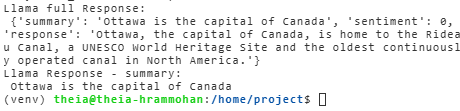

<h1>Enhancing Your Flask Application with AI </h1>Capabilities

update app.py code

In [ ]:
from flask import Flask, request, jsonify, render_template
from model import llama_response, granite_response, mistral_response
import time

app = Flask(__name__)

@app.route('/', methods=['GET'])
def index():
    return render_template('index.html')

@app.route('/generate', methods=['POST'])
def generate():
    data = request.json
    user_message = data.get('message')
    model = data.get('model')
    
    if not user_message or not model:
        return jsonify({"error": "Missing message or model selection"}), 400
    
    system_prompt = "You are an AI assistant helping with customer inquiries. Provide a helpful and concise response."
    
    start_time = time.time()
    
    try:
        if model == 'llama':
            result = llama_response(system_prompt, user_message)
        elif model == 'granite':
            result = granite_response(system_prompt, user_message)
        elif model == 'mistral':
            result = mistral_response(system_prompt, user_message)
        else:
            return jsonify({"error": "Invalid model selection"}), 400
        
        result['duration'] = time.time() - start_time
        return jsonify(result)
    except Exception as e:
        return jsonify({"error": str(e)}), 500

if __name__ == '__main__':
    app.run(debug=True)


Let's break down the changes:

We import our model-specific response functions.
In the /generate route, we now expect JSON input with 'message' and 'model' fields.
We add error handling for missing inputs.
We use a try-except block to handle potential errors in AI processing.
We measure and include the processing time in the response.
This setup allows us to handle requests for different models and provides robust error handling.

<h2> Step 2: Create the Simple HTML file </h2>
create index.html file with following code

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>AI Assistant</title>
    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
    <link href="https://fonts.googleapis.com/css2?family=IBM+Plex+Sans:ital,wght@0,300;0,400;0,500;0,600;1,400&display=swap" rel="stylesheet">
    <link rel="stylesheet" href="/static/styles.css">
</head>
<body class="font-ibm-plex">
    <div class="app-container">
        <!-- Header -->
        <div class="header">
            <div class="header-content">
                <h1 class="header-title">AI Assistant</h1>
                <button id="clearBtn" class="clear-btn" style="display: none;">
                    <svg width="16" height="16" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2">
                        <path d="m3 6 18 0"></path>
                        <path d="M19 6v14c0 1-1 2-2 2H7c-1 0-2-1-2-2V6"></path>
                        <path d="M8 6V4c0-1 1-2 2-2h4c1 0 2 1 2 2v2"></path>
                    </svg>
                    Clear Chat
                </button>
            </div>
        </div>

        <!-- Chat Container -->
        <div class="chat-container">
            <!-- Messages Area -->
            <div class="messages-area">
                <div class="messages-content">
                    <!-- Welcome Screen -->
                    <div id="welcomeScreen" class="welcome-screen">
                        <div class="welcome-icon">
                            <svg width="32" height="32" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.5">
                                <path d="M12 2C6.48 2 2 6.48 2 12s4.48 10 10 10 10-4.48 10-10S17.52 2 12 2z"/>
                                <path d="M8 14s1.5 2 4 2 4-2 4-2"/>
                                <line x1="9" y1="9" x2="9.01" y2="9"/>
                                <line x1="15" y1="9" x2="15.01" y2="9"/>
                            </svg>
                        </div>
                        <h2 class="welcome-title">Welcome to AI Assistant</h2>
                        <p class="welcome-text">Choose a model and start a conversation. I'm here to help with your questions and tasks.</p>
                    </div>

                    <!-- Messages Container -->
                    <div id="messagesContainer" class="messages-container"></div>

                    <!-- Loading Indicator -->
                    <div id="loadingIndicator" class="loading-indicator" style="display: none;">
                        <div class="loading-bubble">
                            <div class="loading-content">
                                <div class="loading-dots">
                                    <div class="dot"></div>
                                    <div class="dot"></div>
                                    <div class="dot"></div>
                                </div>
                                <span class="loading-text">AI is thinking...</span>
                            </div>
                        </div>
                    </div>

                    <!-- Messages End -->
                    <div id="messagesEnd"></div>
                </div>
            </div>

            <!-- Input Area -->
            <div class="input-area">
                <div class="input-content">
                    <form id="chatForm" class="chat-form">
                        <!-- Model Selection -->
                        <div class="model-section">
                            <span class="model-label">Model:</span>
                            <div class="select-wrapper">
                                <select id="modelSelect" class="model-select">
                                    <option value="llama">Llama</option>
                                    <option value="granite">Granite</option>
                                    <option value="mistral">Mistral</option>
                                </select>
                            </div>
                        </div>

                        <!-- Message Input -->
                        <div class="input-section">
                            <div class="textarea-container">
                                <textarea 
                                    id="messageInput" 
                                    class="message-textarea"
                                    placeholder="Type your message... (Enter to send, Shift+Enter for new line)"
                                    rows="1"
                                ></textarea>
                            </div>
                            
                            <button type="submit" id="sendButton" class="send-button">
                                <svg id="sendIcon" width="16" height="16" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2">
                                    <line x1="22" y1="2" x2="11" y2="13"></line>
                                    <polygon points="22,2 15,22 11,13 2,9 22,2"></polygon>
                                </svg>
                                <div id="loadingSpinner" class="loading-spinner" style="display: none;">
                                    <div class="spinner"></div>
                                </div>
                            </button>
                        </div>
                    </form>
                </div>
            </div>
        </div>
    </div>

    <script src="/static/script.js"></script>
</body>
</html>


<h2>Step 3: Adding CSS and JavaScript to Flask</h2>

When building a Flask web application, the HTML templates define the structure and content of your pages, but to make them visually appealing and interactive, we'll need to add CSS and JavaScript. Flask serves these static assets from a dedicated static folder. The CSS and JavaScript code for the frontend of this website is quite long, so instead of embedding it directly in the markdown (which would be messy and hard to read), we’ve kept things clean by hosting the files separately. To add the code, we can create a static folder in our Flask project and download the files from a GitHub Gist. Execute the below commands in the terminal one by one in order:

mkdir static

wget -O static/script.js "https://gist.githubusercontent.com/tenzinmigmar/0168709391266a8d8da7936f1a866c71/raw/95f4f4e1a1966b3f5183dd2f822cfcfd08d2238a/script.js"

wget -O static/styles.css "https://gist.githubusercontent.com/tenzinmigmar/278575598f79a4940993a1fc8640a60a/raw/24eda98885e854b01b4a46d1756112e91d3acc10/styles.css"

<h2>Step 4: Testing Your AI-Enabled Application</h2>

First let's run our Flask application, execute:

python3.11 /home/project/genai_flask_app/app.py

You should see output indicating that the Flask development server is running on port 5000.

The Flask application is now running locally on Cloud IDE. To access it click the following button

[[Test Your Application Button]]

Try this with different messages and models to see how the responses vary.

Congratulations you've created your LLM-enabled Flask Application!

App does not seem to be working though (I typed - hows weather in Mountain House, California). Screenshot -

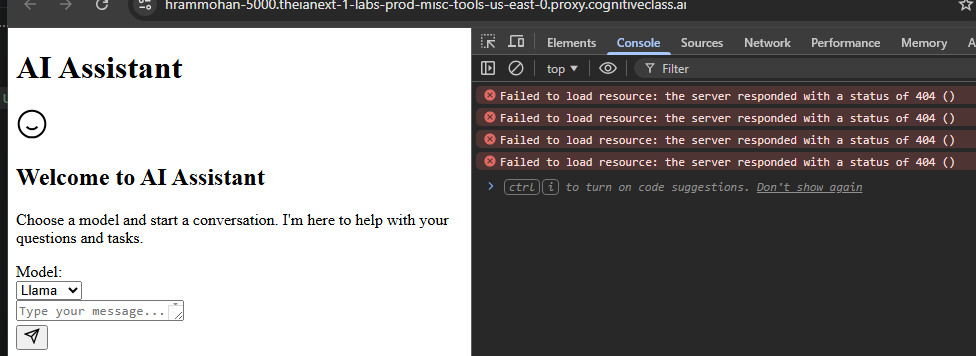


Congratulations on completing this guided project! You've successfully built a backend for a GenAI application using Flask, integrated multiple AI models, and implemented structured JSON outputs for enhanced functionality.

Key Takeaways
You've learned to set up a Flask application with AI capabilities.
You've integrated and compared multiple language models (Llama, Granite, Mistral).
You've implemented LangChain's JsonOutputParser for structured AI outputs.
You've gained insights into prompt engineering and model performance analysis.
You've created a modular and maintainable codebase for AI integration.
Next Steps
To further enhance your skills and application:

Implement Caching: Add a caching mechanism to improve performance for repeated queries.

Explore Advanced LangChain Features: Look into features like memory for maintaining conversation context.

Add More Models: Try integrating other models available through watsonx.ai.

Implement A/B Testing: Create a system to compare responses from different models for the same query.

Enhance Error Handling: Implement more robust error handling and logging.

Explore IBM Cloud Services: Consider integrating other IBM Cloud services to expand your application's capabilities.

Further Learning
Learn about agentic AI (https://cognitiveclass.ai/learn/agentic-ai-hands-on) with our hands-on learning path containing more guided projects just like this one.
Explore the IBM watsonx.ai (https://www.ibm.com/products/watsonx-ai?utm_source=skills_network&utm_content=in_lab_content_link&utm_id=Lab-Build+your+first+GenAI+application+the+right+way_v1_1727277569) documentation for more advanced features.
Dive deeper into LangChain (https://docs.langchain.com/oss/python/langchain/quickstart) for more sophisticated AI application architectures.
Learn about prompt engineering techniques (https://www.ibm.com/think) to improve AI model outputs.
Remember, the field of GenAI is rapidly evolving. Keep experimenting, learning, and building to stay at the forefront of this exciting technology!

Thank you for participating in this workshop. We hope you found it valuable and are inspired to continue your journey in AI-driven application development!